In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from tqdm import tqdm
import seaborn as sns

plt.rc('font', size = 12)
plt.rc('xtick', labelsize = 11)
plt.rc('ytick', labelsize = 11)
plt.rc('legend', fontsize = 10)
plt.rc('axes', labelsize = 12)

aa = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y','-']
aa_id = {}
for id, a in enumerate(aa): aa_id[a]= id

WT="NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKST"
    
q = 20
L = 178

BEGIN = 18
END = 5

WT_SEQ = np.array([aa_id[char] for char in WT])
WT_SEQ = WT_SEQ[BEGIN:-END]
WT_SEQ

array([15, 17, 19,  0, 18, 11, 14,  8, 14,  7, 15, 11,  1, 17,  0,  2, 19,
       15, 17,  9, 19, 11, 15,  0, 15,  4, 15, 16,  4,  8,  1, 19,  5, 17,
       15, 12, 16,  8,  9, 11,  2,  9,  1,  4, 16, 11, 17, 19,  0,  2, 15,
        4, 17,  7, 14,  5,  2,  3, 17, 14, 13,  7,  0, 12,  5, 13, 16,  5,
        8,  7,  0,  2, 19, 11, 19,  8,  9, 12,  2,  2,  4, 16,  5,  1, 17,
        7,  0, 18, 11, 15, 11, 11,  9,  2, 15,  8, 17,  5,  5, 11, 19, 11,
       19,  9, 19, 14,  9,  4, 14,  8, 15, 11,  9,  8, 12,  4,  3, 14,  2,
        7, 15, 16,  3,  7, 19, 13,  0,  5, 15, 16, 12,  1, 11,  5, 17,  3,
        5,  4, 11,  1, 19,  4, 12,  9, 13, 15, 19,  5,  4, 13, 12, 16, 11,
        5, 17,  5, 19, 13, 12, 19, 14, 17, 17, 17,  9, 15,  4,  3,  9,  9,
        6,  0, 12,  0, 16, 17,  1,  5])

In [16]:
def train_test_split(delta, G, test_size = 0.5):
    Mtot, N = delta.shape
    idx = np.random.permutation(Mtot)      
    delta = delta[idx]
    G = G[idx]
    Mtest =  int(Mtot*test_size)
    delta_test = delta[:Mtest, :]
    delta_train = delta[Mtest:,:]
    G_test = G[:Mtest]
    G_train = G[Mtest:] 
    return delta_train, delta_test, G_train, G_test

In [7]:
def ridge_regression_stable(delta, G, lam):
    n, p = delta.shape

    delta_mean = np.mean(delta, axis=0)
    X = delta - delta_mean[None, :]

    G_mean = np.mean(G)
    y = G - G_mean

    # SVD of X (not X.T @ X) — avoids squaring the condition number
    U, s, Vt = np.linalg.svd(X, full_matrices=False)

    # Ridge solution: V @ diag(s / (s² + n*lam)) @ U.T @ y
    d = s / (s**2 + n * lam)
    g_hat = Vt.T @ (d * (U.T @ y))

    return g_hat, delta_mean, G_mean
def ridge_regression(delta, G, lam):

    n, p = delta.shape

    delta_mean = np.mean(delta, axis = 0)

    X = delta - delta_mean[None,:]

    G_mean = np.mean(G)

    y = G - G_mean
    
    g_hat = np.linalg.solve(X.T@X + n * lam * np.eye(p), X.T @ y)

    return g_hat, delta_mean, G_mean

In [24]:
exp_data_path = 'exp_data/'
q = 20
AB = 'S2X16'
with open(exp_data_path+"starr_nature/DMS_"+AB+".csv", 'r') as file:
    line = file.readline().split(sep = ',')
    M = int(line[0])
    N = int(line[1])
    print(M,N)

    delta = np.zeros((M,N),dtype = np.float64)
    G = np.zeros(M,dtype = np.float64)
    for m in range(M):
        line = file.readline().split(sep = ',')
        delta[m] = [int(line[i]) for i in range(N)]
        G[m] = float(line[-1])
        
# remove gap (and WT)
def get_cols_to_remove(L, q, WT):
    cols = set()
    for site in range(L):
        base = site * (q+1)
        cols.add(base + q )       # ultima feature del sito
        #cols.add(base + WT[site])     # feature wild-type del sito
    return sorted(cols)

cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]

delta_new = delta[:, cols_to_keep]
print(f"Shape originale: {delta.shape}")
print(f"Colonne rimosse: {len(cols_to_remove)}")
print(f"Shape finale:    {delta_new.shape}") 
delta = delta_new.copy()

1672 3738
Shape originale: (1672, 3738)
Colonne rimosse: 178
Shape finale:    (1672, 3560)


In [27]:
n_trials = 30

split_fractions = [0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.8,0.85,0.9,0.95,0.975]
mu_grid = 10**(np.array([-9,-8,-7,-6.5,-6,-5.5,-5,-4.5,-4,-3.5,-3,-2,-1,0]))
r_values = np.zeros(len(split_fractions))
risk_values = np.zeros((len(split_fractions), len(mu_grid), n_trials))

from tqdm import tqdm

for i, test_size in enumerate(split_fractions):

    print(i)

    for j, mu in enumerate(mu_grid):

        for trial in tqdm(range(n_trials)):

            delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=test_size)

            if j == 0 and trial == 0: r_values[i] = q * L / len(G_train)

            if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
            else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
            X_test = delta_test - delta_mean[None,:]
            G_pred = X_test @ g_hat + G_mean
            risk_values[i,j,trial] = np.mean((G_pred-G_test)**2)
        print(np.mean(risk_values[i,j,:]))

avg_risk = np.mean(risk_values  , axis = 2)
std_risk = np.std(risk_values, axis = 2)/np.sqrt(n_trials)      

0


100%|██████████| 30/30 [01:07<00:00,  2.25s/it]


0.44308783094079623


100%|██████████| 30/30 [01:14<00:00,  2.48s/it]


0.4217594430550118


...

1.5425295769554523


100%|██████████| 30/30 [00:16<00:00,  1.83it/s]


1.6712548282746087


100%|██████████| 30/30 [00:16<00:00,  1.86it/s]

1.7798853743979461


In [28]:
data = pd.DataFrame({'Ab': [],'q':[], 'L': [], 'M': [], 'r': [], 'mu': [], 'R': [], 'sR': [],'nTest': [],'nTrial': []}) 

In [29]:
for j, mu in enumerate(mu_grid):
    for i, r in enumerate(r_values):
        data = pd.concat([data, pd.DataFrame({'Ab': [AB],'q':[q], 'L': [L], 'M': [int(q*L/r)], 'r': [r], 'mu': [mu], 'R': [avg_risk[i,j]], 'sR': [std_risk[i,j]],'nTest': [int(split_fractions[i]*len(G))],'nTrial': [n_trials]})])

In [30]:
outfile = "exp_data/test_risk/"+AB+".csv"
data.to_csv(outfile, index = False)

In [32]:
outfile = "exp_data/test_risk/"+AB+".csv"
data = pd.read_csv(outfile)
data

,Ab,q,L,M,r,mu,R,sR,nTest,nTrial
0,S2X16,20.0,178.0,1589.0,2.240403,1.000000e-09,0.443088,0.045117,83.0,30.0
1,S2X16,20.0,178.0,1422.0,2.503516,1.000000e-09,0.375417,0.019235,250.0,30.0
2,S2X16,20.0,178.0,1254.0,2.838915,1.000000e-09,0.415717,0.016608,418.0,30.0
3,S2X16,20.0,178.0,1087.0,3.275069,1.000000e-09,0.425967,0.010249,585.0,30.0
4,S2X16,20.0,178.0,920.0,3.869565,1.000000e-09,0.427460,0.008156,752.0,30.0
...,...,...,...,...,...,...,...,...,...,...
177,S2X16,20.0,178.0,335.0,10.626866,1.000000e+00,1.737592,0.011932,1337.0,30.0
178,S2X16,20.0,178.0,251.0,14.183267,1.000000e+00,1.726687,0.010314,1421.0,30.0
179,S2X16,20.0,178.0,168.0,21.190476,1.000000e+00,1.747672,0.008137,1504.0,30.0
180,S2X16,20.0,178.0,84.0,42.380952,1.000000e+00,1.766016,0.009561,1588.0,30.0


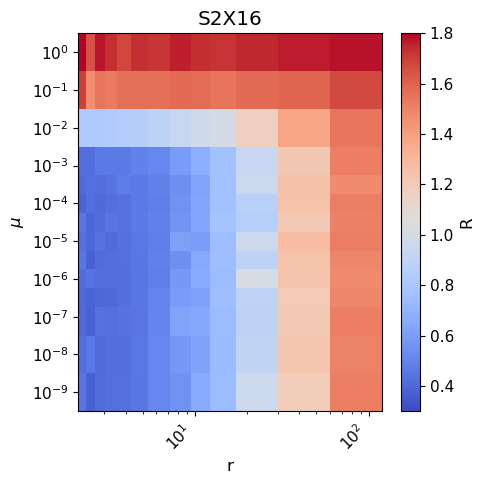

In [33]:


fig, ax = plt.subplots(1, 1)
fig.set_figheight(5)
fig.set_figwidth(5)

AB = "S2X16"
temp = data[(data['Ab'] == AB)]

pivot = temp.pivot(index='mu', columns='r', values='R')
densities = pivot.columns.values  # mu
temps = pivot.index.values        # r
Z = pivot.values

# Edges in log space
log_d = np.log10(densities)
x_edges = 10**np.concatenate((
    [log_d[0] - (log_d[1] - log_d[0]) / 2],
    (log_d[:-1] + log_d[1:]) / 2,
    [log_d[-1] + (log_d[-1] - log_d[-2]) / 2]
))

log_t = np.log10(temps)
y_edges = 10**np.concatenate((
    [log_t[0] - (log_t[1] - log_t[0]) / 2],
    (log_t[:-1] + log_t[1:]) / 2,
    [log_t[-1] + (log_t[-1] - log_t[-2]) / 2]
))

im = ax.pcolormesh(x_edges, y_edges, Z, cmap='coolwarm',
                   shading='auto', vmin=0.3, vmax=1.8)

ax.set_xscale('log')
ax.set_yscale('log')

# Let matplotlib pick clean log ticks automatically
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=12))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Remove minor ticks clutter
#ax.xaxis.set_minor_locator(ticker.NullLocator())
#ax.yaxis.set_minor_locator(ticker.NullLocator())

plt.xticks(rotation=45, ha='right')

plt.colorbar(im, ax=ax, label='R')
ax.set_title(AB)
ax.set_xlabel('r')
ax.set_ylabel('$\\mu$')

plt.tight_layout()
plt.show()

In [34]:
mu_opt = []
smu_opt = []
mu_max = []
mu_min = []
R_opt = []
r_values = []

for id, temp in data.groupby("r"):

    id_opt = np.argmin(temp['R'].values)
    row_opt = temp.iloc[id_opt] 
    R_opt_temp = row_opt['R']
    sR_opt_temp = row_opt['sR']
    mus = []
    for row_id, row in temp.iterrows(): 
        if row['R'] - R_opt_temp < np.sqrt(sR_opt_temp**2+row['sR']**2): mus.append(row['mu'])

    mu_opt.append(row_opt['mu'])
    smu_opt.append(np.std(mus))
    mu_min.append(np.min(mus)) 
    mu_max.append(np.max(mus)) 
    R_opt.append(row_opt['R'])
    r_values.append(row_opt['r'])

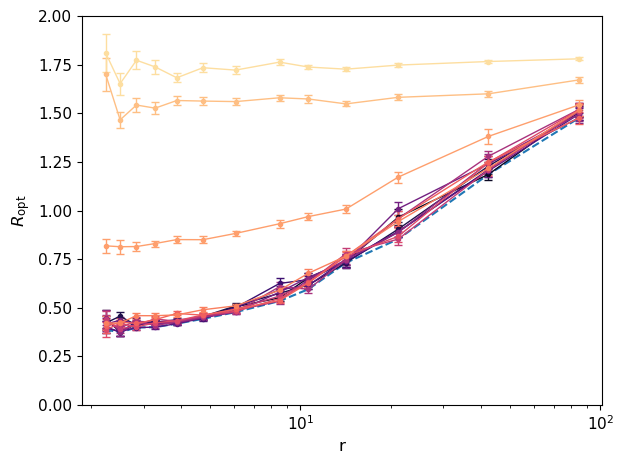

In [35]:
colors = sns.color_palette("magma", len(data['mu'].unique()))
i = -1
for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    i += 1
    temp.sort_values(by = 'r', inplace=True)
    plt.errorbar(temp['r'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])

plt.plot(r_values, R_opt, linestyle = '--')
plt.ylim(0,2)
plt.xscale("log")
plt.xlabel("r")
plt.ylabel('$R_{\\text{opt}}$')
plt.tight_layout()
plt.show()

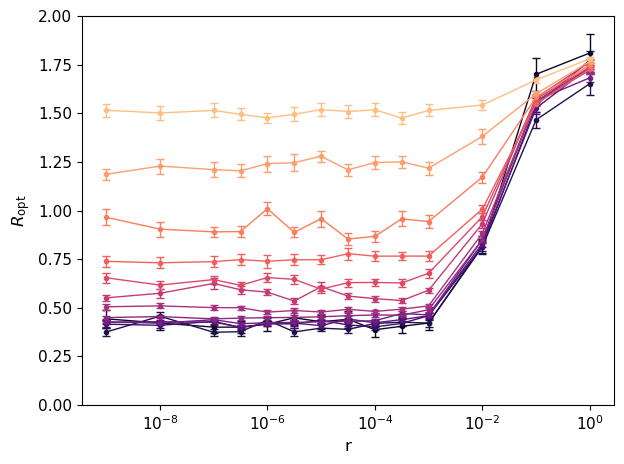

In [37]:
colors = sns.color_palette("magma", len(data['mu'].unique()))
i = -1
for id, temp in data.sort_values(by = 'r').groupby("r"):
    i += 1
    temp.sort_values(by = 'mu', inplace=True)
    plt.errorbar(temp['mu'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])

plt.ylim(0,2)
plt.xscale("log")
plt.xlabel("r")
plt.ylabel('$R_{\\text{opt}}$')
plt.tight_layout()
plt.show()

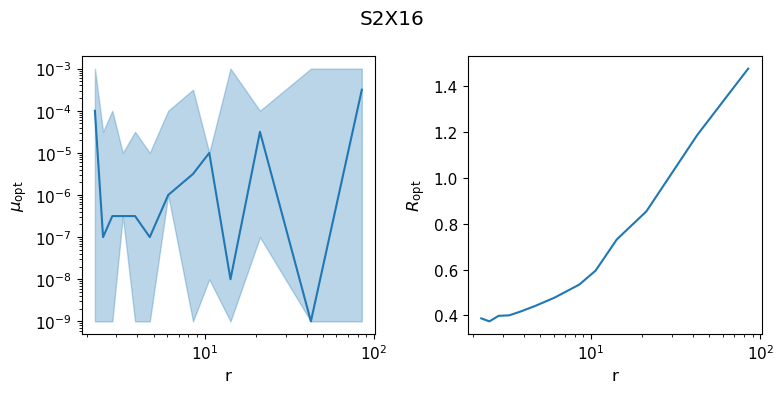

In [38]:
fig, [ax1, ax2] = plt.subplots(1,2) 
fig.set_figheight(4)
fig.set_figwidth(8)

fig.suptitle(AB)

#ax1.errorbar(r_values, mu_opt, smu_opt)
ax1.plot(r_values, mu_opt)
ax1.fill_between(r_values, mu_min, mu_max, alpha = 0.3, color = 'C0')

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("r")
ax1.set_ylabel('$\\mu_{\\text{opt}}$')

"""colors = sns.color_palette("magma", len(mu_grid))
i = -1
for id, temp in data.groupby("mu"):
    i += 1
    ax2.errorbar(temp['r'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])"""

ax2.plot(r_values, R_opt)
ax2.set_xscale("log")
ax2.set_xlabel("r")
ax2.set_ylabel('$R_{\\text{opt}}$')

plt.tight_layout()
plt.show()

In [39]:
mu_values = []
Rmin_values = [] 

for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    temp = temp[temp['r']<5]
    Rmin = np.sum(temp['R']*temp['sR']**2)/np.sum(temp['sR']**2)
    mu_values.append(id)
    Rmin_values.append(Rmin)

0.2253536533040482


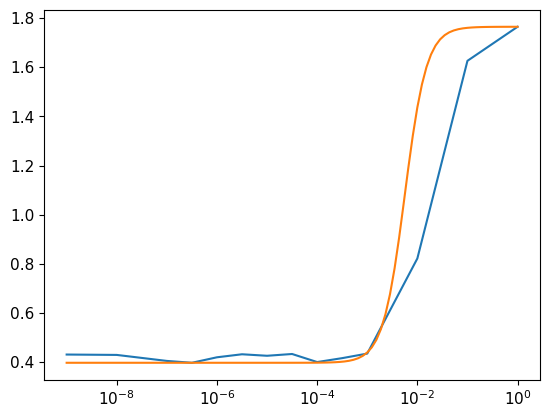

In [40]:
mu_values = np.array(mu_values)
Rmin_values = np.array(Rmin_values)

plt.plot(mu_values, Rmin_values)

R0 = np.min(Rmin_values)
SNR = Rmin_values[-1]*(1+(L*mu_values[-1])**2)/(L*mu_values[-1])**2-R0 
Fmis = R0/(R0+SNR)
print(Fmis)

mus = np.geomspace(10**(-9),1,100)
plt.plot(mus,R0+SNR*(L*mus)**2/(1+(L*mus)**2))
plt.xscale("log")

## Piccolo check

In [252]:
exp_data_path = '../Code/ESCAPE_MAP_DRAFT/exp_data/'
q = 20
with open(exp_data_path+"starr_nature/DMS_"+AB+".csv", 'r') as file:
    line = file.readline().split(sep = ',')
    M = int(line[0])
    N = int(line[1])

    delta = np.zeros((M,N),dtype = np.float32)
    G = np.zeros(M,dtype = np.float64)
    for m in range(M):
        line = file.readline().split(sep = ',')
        delta[m] = [int(line[i]) for i in range(N)]
        G[m] = float(line[-1])
    # remove gap       
    cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
    cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]

    delta_new = delta[:, cols_to_keep]
    delta = delta_new.copy()    

In [279]:
g, delta_mean, G_mean = ridge_regression(delta, G, 10**(-4)) 


In [280]:
g

array([ 0.        ,  0.        ,  0.        , ..., -0.03249184,
        0.        ,  0.        ], shape=(3560,))

In [281]:
g_matrix = g.reshape((len(g)//q, q)) 

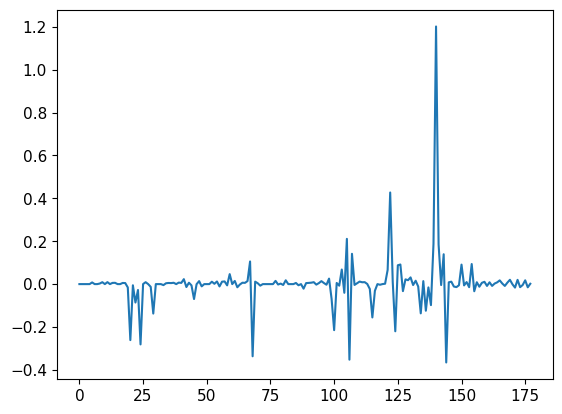

In [285]:
plt.plot(np.mean(g_matrix, axis = 1))

In [274]:
L,q = g_matrix.shape
for site in range(L):
    g_matrix[site,:] -= (np.sum(g_matrix[site,:])-g_matrix[site, WT_SEQ[site]])/(q-1)

In [275]:
norm = np.sum(g_matrix**2)
print(norm)
F = np.sum([g_matrix[site,WT_SEQ[site]]**2 for site in range(L)])/norm
print(F)

932.1161268882338
0.08268488310361792


In [287]:
norms = []
Fs = []
for mu in mu_grid:
    print(mu) 
    g, delta_mean, G_mean = ridge_regression(delta, G, mu) 
    g_matrix = g.reshape((len(g)//q, q)) 
    L,q = g_matrix.shape
    for site in range(L):
        g_matrix[site,:] -= (np.sum(g_matrix[site,:])-g_matrix[site, WT_SEQ[site]])/(q-1)
    norm = np.sum(g_matrix**2)
    F = np.sum([g_matrix[site,WT_SEQ[site]]**2 for site in range(L)])/norm
    norms.append(norm)
    Fs.append(F)

1e-07
1e-06
1e-05
0.0001
0.001
0.01
0.1


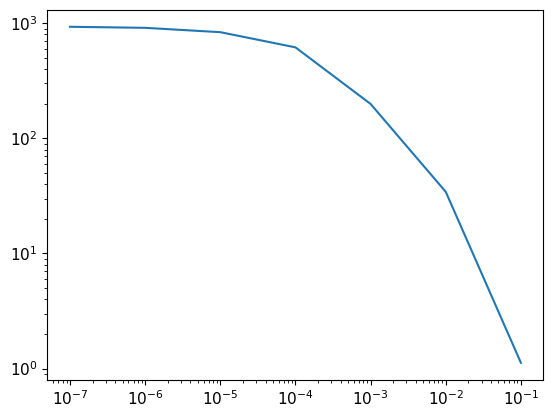

In [290]:
plt.plot(mu_grid, norms)
plt.xscale("log")
plt.yscale("log")

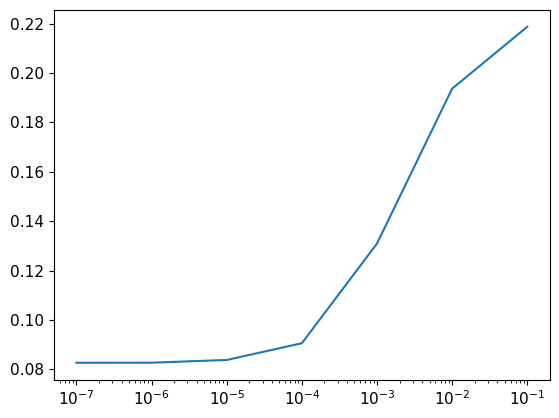

In [291]:
plt.plot(mu_grid, Fs)
plt.xscale("log")

# All antibodies

In [ ]:

abs = pd.read_csv(exp_data_path+"ab_classification.csv")

In [ ]:
exp_data_path = 'exp_data/'
outfile = 'exp_data/test_risk/data.csv'

n_trials = 10
q = 20 
L = len(WT_SEQ)

split_fractions = [0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.8,0.85,0.9,0.95,0.975]
mu_grid = 10**(np.array([-9,-8,-7,-6.5,-6,-5.5,-5,-4.5,-4,-3.5,-3,-2,-1,0]))
r_values = np.zeros(len(split_fractions))


def get_cols_to_remove(L, q, WT):
    cols = set()
    for site in range(L):
        base = site * (q+1)
        cols.add(base + q)       # ultima feature del sito
        #cols.add(base + WT[site])     # feature wild-type del sito
    return sorted(cols)

data = pd.DataFrame({'Ab': [],'q':[], 'L': [], 'M': [], 'r': [], 'mu': [], 'R': [], 'sR': [],'nTest': [],'nTrial': []}) 

for AB in ab_list:

    print(AB)

    with open(exp_data_path+'fasta_files/'+AB+'deltaG.fasta', 'r') as file:
        line = file.readline().split(sep = ',')
        M = int(line[0])
        N = int(line[1])

        delta = np.zeros((M,N),dtype = np.float32)
        G = np.zeros(M,dtype = np.float64)
        for m in range(M):
            line = file.readline().split(sep = ',')
            delta[m] = [int(line[i]) for i in range(N)]
            G[m] = float(line[-1])
    # remove gap       
    cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
    cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]
    
    delta_new = delta[:, cols_to_keep]
    delta = delta_new.copy()
    
    risk_values = np.zeros(n_trials)

    for i, test_size in tqdm(enumerate(split_fractions)):

        for j, mu in enumerate(mu_grid):

            for trial in range(n_trials):

                delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=test_size)

                if j == 0 and trial == 0: r_values[i] = q * L / len(G_train)

                if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
                else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
                X_test = delta_test - delta_mean[None,:]
                G_pred = X_test @ g_hat + G_mean
                risk_values[trial] = np.mean((G_pred-G_test)**2)

            avg_risk = np.mean(risk_values)
            std_risk = np.std(risk_values)/np.sqrt(n_trials)   
        
            data = pd.concat([data, pd.DataFrame({'Ab': [AB],'q':[q], 'L': [L], 'M': [int(q*L/r)], 'r': [r], 'mu': [mu], 'R': [avg_risk], 'sR': [std_risk],'nTest': [int(split_fractions[i]*len(G))],'nTrial': [n_trials]})])
  
data.to_csv(outfile, index = False)    
